# Tóm tắt kết quả Dehazing và Detection

In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import yaml
import sys
sys.path.append('A:/HUST_on_GitHub/ProjectCV')

from ultralytics import YOLO
from src.restoration.dcp import DCPDehazeFilter, DCPConfig
from src.metrics.full_reference import compute_ssim, compute_psnr
from src.metrics.no_reference import compute_brisque

a:\HUST_on_GitHub\ProjectCV\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Tải các cấu hình và mô hình YOLO

In [2]:
import dataclasses

def load_cfg(path):
    with open(path, 'r') as f:
        cfg = yaml.safe_load(f)
    if not cfg:
        return {}
    
    # Chỉ giữ lại các keys có trong DCPConfig
    valid_keys = {field.name for field in dataclasses.fields(DCPConfig)}
    return {k: v for k, v in cfg.items() if k in valid_keys}

configs = {
    "Default": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/configs/dcp_default.yaml')),
    "Optuna_1": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config1_reside_ssim/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config1_reside_ssim/best_config.yaml') else None,
    "Optuna_2": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config2_dawn_brisque/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config2_dawn_brisque/best_config.yaml') else None,
    "Optuna_3": DCPConfig(**load_cfg('A:/HUST_on_GitHub/ProjectCV/results/optuna/config3_dawn_map50/best_config.yaml')) if os.path.exists('A:/HUST_on_GitHub/ProjectCV/results/optuna/config3_dawn_map50/best_config.yaml') else None
}

filters = {k: DCPDehazeFilter(v) for k, v in configs.items() if v is not None}

yolo_model = YOLO('A:/HUST_on_GitHub/ProjectCV/yolo26n.pt')

In [3]:
import cv2
import matplotlib.pyplot as plt
import os
from src.restoration.dcp import DCPDehazeFilter

# Draw Ground Truth BB
def draw_gt_boxes(img, label_path):
    img_copy = img.copy()
    if not os.path.exists(label_path):
        return img_copy
        
    CLASS_NAMES = {
        0: "person",
        1: "bicycle",
        2: "car",
        3: "motorcycle",
        5: "bus",
        7: "truck"
    }

    
    h, w = img_copy.shape[:2]
    with open(label_path, 'r') as f:
        lines = f.readlines()
        
    for line in lines:
        parts = line.strip().split()
        if len(parts) >= 5:
            cls_id = int(parts[0])
            cls_name = CLASS_NAMES.get(cls_id, str(cls_id))
            
            x_center = float(parts[1]) * w
            y_center = float(parts[2]) * h
            box_w = float(parts[3]) * w
            box_h = float(parts[4]) * h
            
            x1 = int(x_center - box_w / 2)
            y1 = int(y_center - box_h / 2)
            x2 = int(x_center + box_w / 2)
            y2 = int(y_center + box_h / 2)
            
            cv2.rectangle(img_copy, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_copy, f"GT: {cls_name}", (x1, max(y1 - 5, 0)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            
    return img_copy


def show_images_yolo(imgs, titles, figsize=(25, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        ax.set_title(title, fontsize=14, pad=10)
        ax.axis('off')
    plt.tight_layout()
    plt.show()


## 2. Bảng kết quả Metrics (Final Evaluation)

In [4]:
eval_csv = 'A:/HUST_on_GitHub/ProjectCV/results/evaluation.csv'
if os.path.exists(eval_csv):
    df = pd.read_csv(eval_csv)
    display(df)
else:
    print("Chưa có file kết quả, hãy chạy 07_evaluation.py")

,Config,RESIDE_SSIM,RESIDE_PSNR,DAWN_BRISQUE,DAWN_NIQE,DAWN_PIQE,DAWN_Entropy,DAWN_mAP50,DAWN_mAP50-95,DAWN_IoU,DAWN_Precision,DAWN_Recall
0,Default,0.844980,17.872084,41.239699,5.339674,48.200980,6.653361,0.467342,0.297121,0.412242,0.657367,0.396866
1,Optuna_SSIM,0.887505,21.140244,42.342641,5.585957,51.267826,6.924755,0.494339,0.308852,0.420484,0.656818,0.429593
2,Optuna_BRISQUE,0.796990,18.465965,38.997026,4.857004,44.998710,7.247004,0.475667,0.298760,0.416229,0.758388,0.366048
3,Optuna_mAP50,0.879861,20.375919,41.770959,5.540926,50.953556,6.882565,0.483949,0.308891,0.413562,0.630847,0.444468


## 3. Trực quan hóa kết quả (RESIDE)
So sánh Hazy vs Ground Truth vs Default vs Config 1


--- Visualization: 0001_0.8_0.2.jpg ---


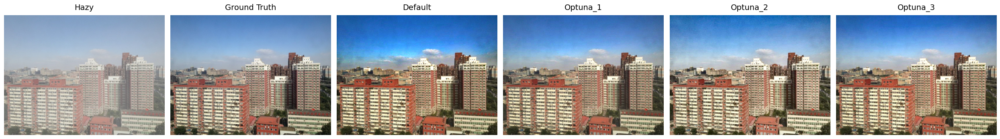


--- Visualization: 0002_0.8_0.08.jpg ---


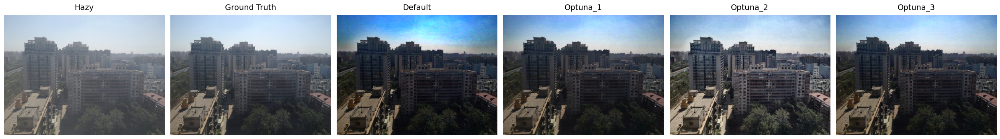


--- Visualization: 0003_0.8_0.2.jpg ---


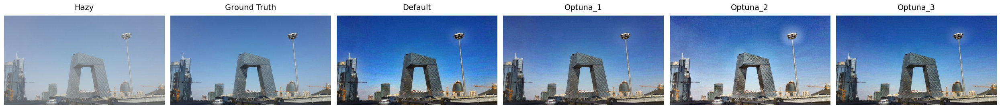


--- Visualization: 0004_0.9_0.12.jpg ---


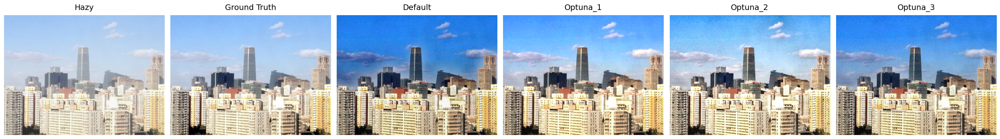


--- Visualization: 0006_0.85_0.08.jpg ---


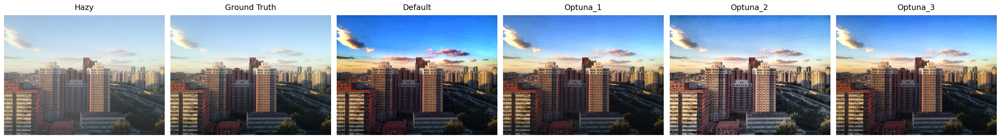

In [5]:
import glob
import os
import cv2
k = 5  # number of sample
reside_hazy_files = glob.glob('A:/HUST_on_GitHub/ProjectCV/dataset/RESIDE-6K/test/hazy/*.jpg')[:k]
for reside_hazy_path in reside_hazy_files:
    basename = os.path.basename(reside_hazy_path)
    reside_gt_path = f'A:/HUST_on_GitHub/ProjectCV/dataset/RESIDE-6K/test/GT/{basename}'
    
    print(f"\n" + "="*50)
    print(f"--- Visualization: {basename} ---")

    if os.path.exists(reside_hazy_path) and os.path.exists(reside_gt_path):
        hazy_img = cv2.imread(reside_hazy_path)
        gt_img = cv2.imread(reside_gt_path)
        
        imgs_reside = [hazy_img, gt_img]
        titles_reside = ["Hazy", "Ground Truth"]
        
        for cfg_name in ["Default", "Optuna_1", "Optuna_2", "Optuna_3"]:
            if cfg_name in configs and configs[cfg_name] is not None:
                dehazer = DCPDehazeFilter(configs[cfg_name])
                res = dehazer.restore(hazy_img)
                imgs_reside.append(res)
                titles_reside.append(f"{cfg_name}")
        show_images_yolo(imgs_reside, titles_reside, figsize=(25, 5))
    else:
        print("Not found")


## 4. Trực quan hóa Detection (DAWN)
Sử dụng YOLOv26 để dự đoán trên ảnh Hazy và ảnh sau khi Dehaze.


--- Visualization: foggy-001 ---
--- RESTORATION ---


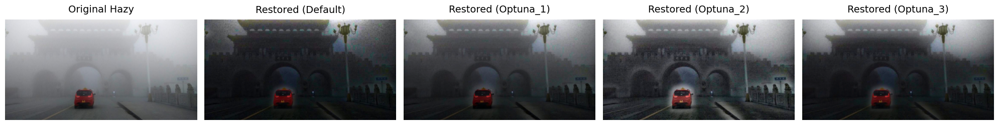


--- DETECTION ---


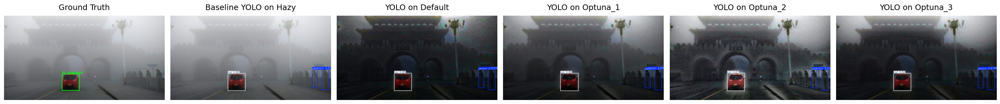


--- Visualization: foggy-002 ---
--- RESTORATION ---


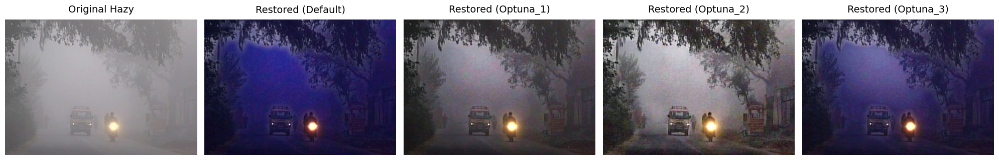


--- DETECTION ---


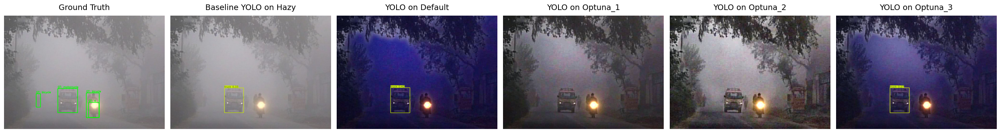


--- Visualization: foggy-003 ---
--- RESTORATION ---


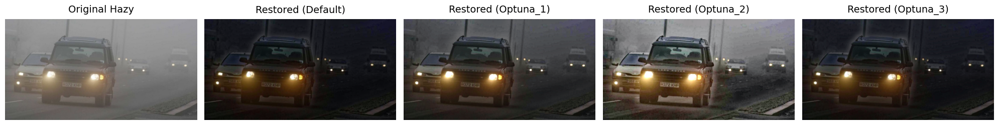


--- DETECTION ---


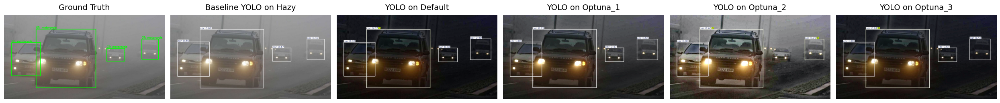


--- Visualization: foggy-004 ---
--- RESTORATION ---


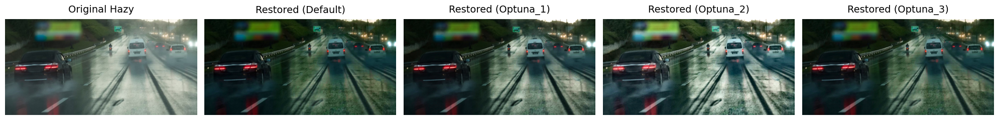


--- DETECTION ---


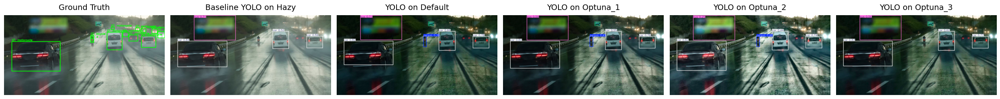


--- Visualization: foggy-006 ---
--- RESTORATION ---


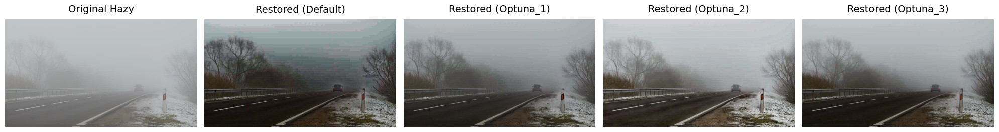


--- DETECTION ---


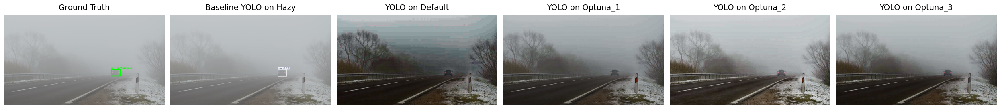

In [9]:
k = 5  # number of sample
weather = 'Fog'
dawn_img_files = glob.glob(f'A:/HUST_on_GitHub/ProjectCV/dataset/DAWN/{weather}/*.jpg')[:k]
for dawn_img_path in dawn_img_files:
    basename = os.path.basename(dawn_img_path)
    basename = basename[:-4]
    dawn_lbl_path = f'A:/HUST_on_GitHub/ProjectCV/dataset/DAWN/{weather}/{weather}_YOLO_darknet/{basename}.txt'

    print(f"\n" + "="*50)
    print(f"--- Visualization: {basename} ---")

    if os.path.exists(dawn_img_path):
        dawn_img = cv2.imread(dawn_img_path)
        
        # --- PHẦN 1: SO SÁNH ẢNH KHÔI PHỤC ---
        print("--- RESTORATION ---")
        imgs_dawn_restored = [dawn_img.copy()]
        titles_dawn_restored = ["Original Hazy"]
        dehazed_dict = {}
        
        for cfg_name in ["Default", "Optuna_1", "Optuna_2", "Optuna_3"]:
            if cfg_name in configs and configs[cfg_name] is not None:
                dehazer = DCPDehazeFilter(configs[cfg_name])
                res = dehazer.restore(dawn_img)
                imgs_dawn_restored.append(res)
                titles_dawn_restored.append(f"Restored ({cfg_name})")
                dehazed_dict[cfg_name] = res
                
        show_images_yolo(imgs_dawn_restored, titles_dawn_restored, figsize=(20, 5))
        
        # --- PHẦN 2: SO SÁNH NHẬN DIỆN VẬT THỂ (DETECTION) ---
        print("\n--- DETECTION ---")
        imgs_dawn_det = []
        titles_dawn_det = []
        
        # 1. Ground Truth (Vẽ BB xanh lá lên ảnh gốc)
        gt_plotted = draw_gt_boxes(dawn_img, dawn_lbl_path)
        imgs_dawn_det.append(gt_plotted)
        titles_dawn_det.append("Ground Truth")
        
        # 2. Baseline (YOLO dự đoán trực tiếp trên Hazy)
        res_baseline = yolo_model.predict(dawn_img, verbose=False, classes=[0, 1, 2, 3, 5, 7])[0]
        imgs_dawn_det.append(res_baseline.plot(line_width=2))
        titles_dawn_det.append("Baseline YOLO on Hazy")
        
        # 3. Kết quả YOLO trên các cấu hình đã dehaze
        for cfg_name in ["Default", "Optuna_1", "Optuna_2", "Optuna_3"]:
            if cfg_name in dehazed_dict:
                res_det = yolo_model.predict(dehazed_dict[cfg_name], verbose=False, classes=[0, 1, 2, 3, 5, 7])[0]
                imgs_dawn_det.append(res_det.plot(line_width=2))
                titles_dawn_det.append(f"YOLO on {cfg_name}")
                
        show_images_yolo(imgs_dawn_det, titles_dawn_det, figsize=(25, 5))
    else:
        print("Not found DAWN dataset")
